# lda_dcabp_evolution

Evolution of LDA behavioral patterns over time per patient.

1. Load the **day-type sequences**, the trained **LDA model** and the **dictionary**.
2. Attach the clinical dates / event info.
3. Build the **monthly predominant topic** table (30-day blocks).
4. Global plots:
   - **Predominant topic per month** heatmap (6 topics).
   - **Hypertopic per month** heatmap (favorable vs unfavorable groups).
   - **Individual topic evolution** per patient (daily 30-day windows).


In [1]:
import ast
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from gensim import corpora
from gensim.models import LdaModel

def find_project_root() -> Path:
    cwd = Path.cwd()
    if cwd.name == "notebooks":
        return cwd.parent
    if cwd.name == "vq-vae_lda_pipeline":
        return cwd.parent.parent
    for p in (cwd, *cwd.parents):
        if (p / "models").is_dir() and (p / "data").is_dir():
            return p
    return cwd


def rel_path(path: Path) -> str:
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


PROJECT_ROOT = find_project_root()

# Trained LDA artifacts
LDA_MODEL_PATH = PROJECT_ROOT / "models/lda/LDA_model_vdec25.gensim"
DICTIONARY_PATH = PROJECT_ROOT / "models/lda/dictionary_LDA_vdec25.dict"

# eB2 table with day-type sequences (id, embedding_ids) + clinical dates/event
DF_DAY_CSV = PROJECT_ROOT / "data/processed/lda/PD_cutoff_dic_2025s_eB2_Topics_a0_6topics100000.csv"

# Clinical / event columns in DF_DAY_CSV (English; run rename_eb2_csv_columns.py once if needed)
DATE_COLS = [
    "date_start_hdm", "pd_event", "obs_time_final",
    "time_difference", "pd_event_diff", "early_pd", "first_eb2_record",
]

# Reuse the monthly-topics helper from the scripts package
SCRIPTS_LDA = PROJECT_ROOT / "scripts/03_analysis/lda"
if str(SCRIPTS_LDA) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_LDA))

WINDOW_SIZE = 30
MIN_EMBEDDINGS = 15

TABLES_DIR = PROJECT_ROOT / "results/lda/tables"
FIG_DIR = PROJECT_ROOT / "results/lda/figures"




## 1 · Load embeddings, LDA model and dictionary

In [3]:
lda_model = LdaModel.load(str(LDA_MODEL_PATH))
dictionary = corpora.Dictionary.load(str(DICTIONARY_PATH))
NUM_TOPICS = lda_model.num_topics
print(f"LDA topics: {NUM_TOPICS} | dictionary size: {len(dictionary)}")

df = pd.read_csv(DF_DAY_CSV)
df["embedding_ids"] = df["embedding_ids"].apply(
    lambda v: ast.literal_eval(v) if isinstance(v, str) else v
)
df["id"] = pd.to_numeric(df["id"], errors="coerce").astype("Int64")
print("Patients:", len(df))
df.head()


LDA topics: 6 | dictionary size: 255
Patients: 175


,id,predominant_topic,topic_distribution,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,embedding_ids,date_start_hdm,pd_event,obs_time_final,time_difference,pd_event_diff,early_pd,first_eb2_record
0,11001,3,"[0.00019024033, 0.094892785, 0.00019086628, 0....",0.000190,0.094893,0.000191,0.692382,0.017605,0.194739,"[67, 34, 194, 7, 76, 49, 95, 62, 131, 175, 58,...",2023-04-19,0,876,0.0,876.0,0,NaN
1,11003,3,"[0.00047766662, 0.056067478, 0.023019955, 0.67...",0.000478,0.056067,0.023020,0.670386,0.068694,0.181354,"[46, 13, 184, 225, 192, 224, 72, 224, 197, 180...",2023-12-05,1,357,8.0,349.0,0,13/12/23
2,11004,2,"[0.00026418606, 0.12145818, 0.51455325, 0.2545...",0.000264,0.121458,0.514553,0.254527,0.082532,0.026666,"[43, 43, 218, 210, 77, 34, 243, 125, 125, 218,...",2023-12-20,0,631,0.0,631.0,0,NaN
3,11005,1,"[0.031426333, 0.7207797, 0.1621154, 0.00031404...",0.031426,0.720780,0.162115,0.000314,0.000315,0.085049,"[238, 172, 50, 110, 125, 117, 18, 18, 149, 14,...",2024-03-27,0,533,0.0,533.0,0,NaN
4,11006,2,"[0.0005627643, 0.072490364, 0.63257277, 0.0005...",0.000563,0.072490,0.632573,0.000568,0.293243,0.000563,"[247, 69, 91, 142, 125, 208, 208, 15, 247, 51,...",2024-11-20,0,295,0.0,295.0,0,NaN


## 2 · Select day-type sequences + clinical dates / event



In [4]:
missing = [c for c in DATE_COLS if c not in df.columns]
if "pd_event" in missing or "pd_event_diff" in missing:
    raise KeyError(f"eB2 CSV is missing required columns: {missing}")

keep = ["id", "embedding_ids"] + [c for c in DATE_COLS if c in df.columns]
df_day = df[keep].copy()
print("df_day:", df_day.shape)
df_day[["id", "pd_event", "pd_event_diff"]].head()

df_day: (175, 9)


,id,pd_event,pd_event_diff
0,11001,0,876.0
1,11003,1,349.0
2,11004,0,631.0
3,11005,0,533.0
4,11006,0,295.0


## 3 · Monthly predominant topic table (30-day blocks)

In [5]:
from monthly_topics_utils import (
    build_monthly_predominant_table,
    sort_patients_for_heatmap,
    topic_month_columns,
)

ordered_df = build_monthly_predominant_table(
    df_day, lda_model, dictionary,
    window_size=WINDOW_SIZE, min_embeddings=MIN_EMBEDDINGS,
)

TABLES_DIR.mkdir(parents=True, exist_ok=True)
monthly_csv = TABLES_DIR / "monthly_predominant_topics.csv"
ordered_df.to_csv(monthly_csv, index=False)
print("Saved:", rel_path(monthly_csv))
print("Patients in table:", len(ordered_df))
ordered_df.head()

Saved: results/lda/tables/monthly_predominant_topics.csv
Patients in table: 172


,id,Event,t_evento_eb2,topic_predominante_mes1,topic_predominante_mes2,topic_predominante_mes3,topic_predominante_mes4,topic_predominante_mes5,topic_predominante_mes6,topic_predominante_mes7,...,topic_predominante_mes23,topic_predominante_mes24,topic_predominante_mes25,topic_predominante_mes26,topic_predominante_mes27,topic_predominante_mes28,topic_predominante_mes29,topic_predominante_mes30,topic_predominante_mes31,topic_predominante_mes32
0,11001,0.0,NaN,3,3,5,5,3,3,5,...,3,3,3,3,3,3,3,3,<NA>,<NA>
1,11004,0.0,NaN,3,2,2,2,2,2,2,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,11005,0.0,NaN,1,1,1,1,1,1,1,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,11006,0.0,NaN,2,2,2,2,2,4,2,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,11007,0.0,NaN,2,2,2,2,2,2,2,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## 4 · Global plot 1 — Predominant topic per month (6 topics)

/var/folders/qx/p120p7490sj_nzmspflj0x0h0002wf/T/ipykernel_40329/2602778957.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({pd.NA: np.nan})


Saved: results/lda/figures/predominant_topics_per_month.svg


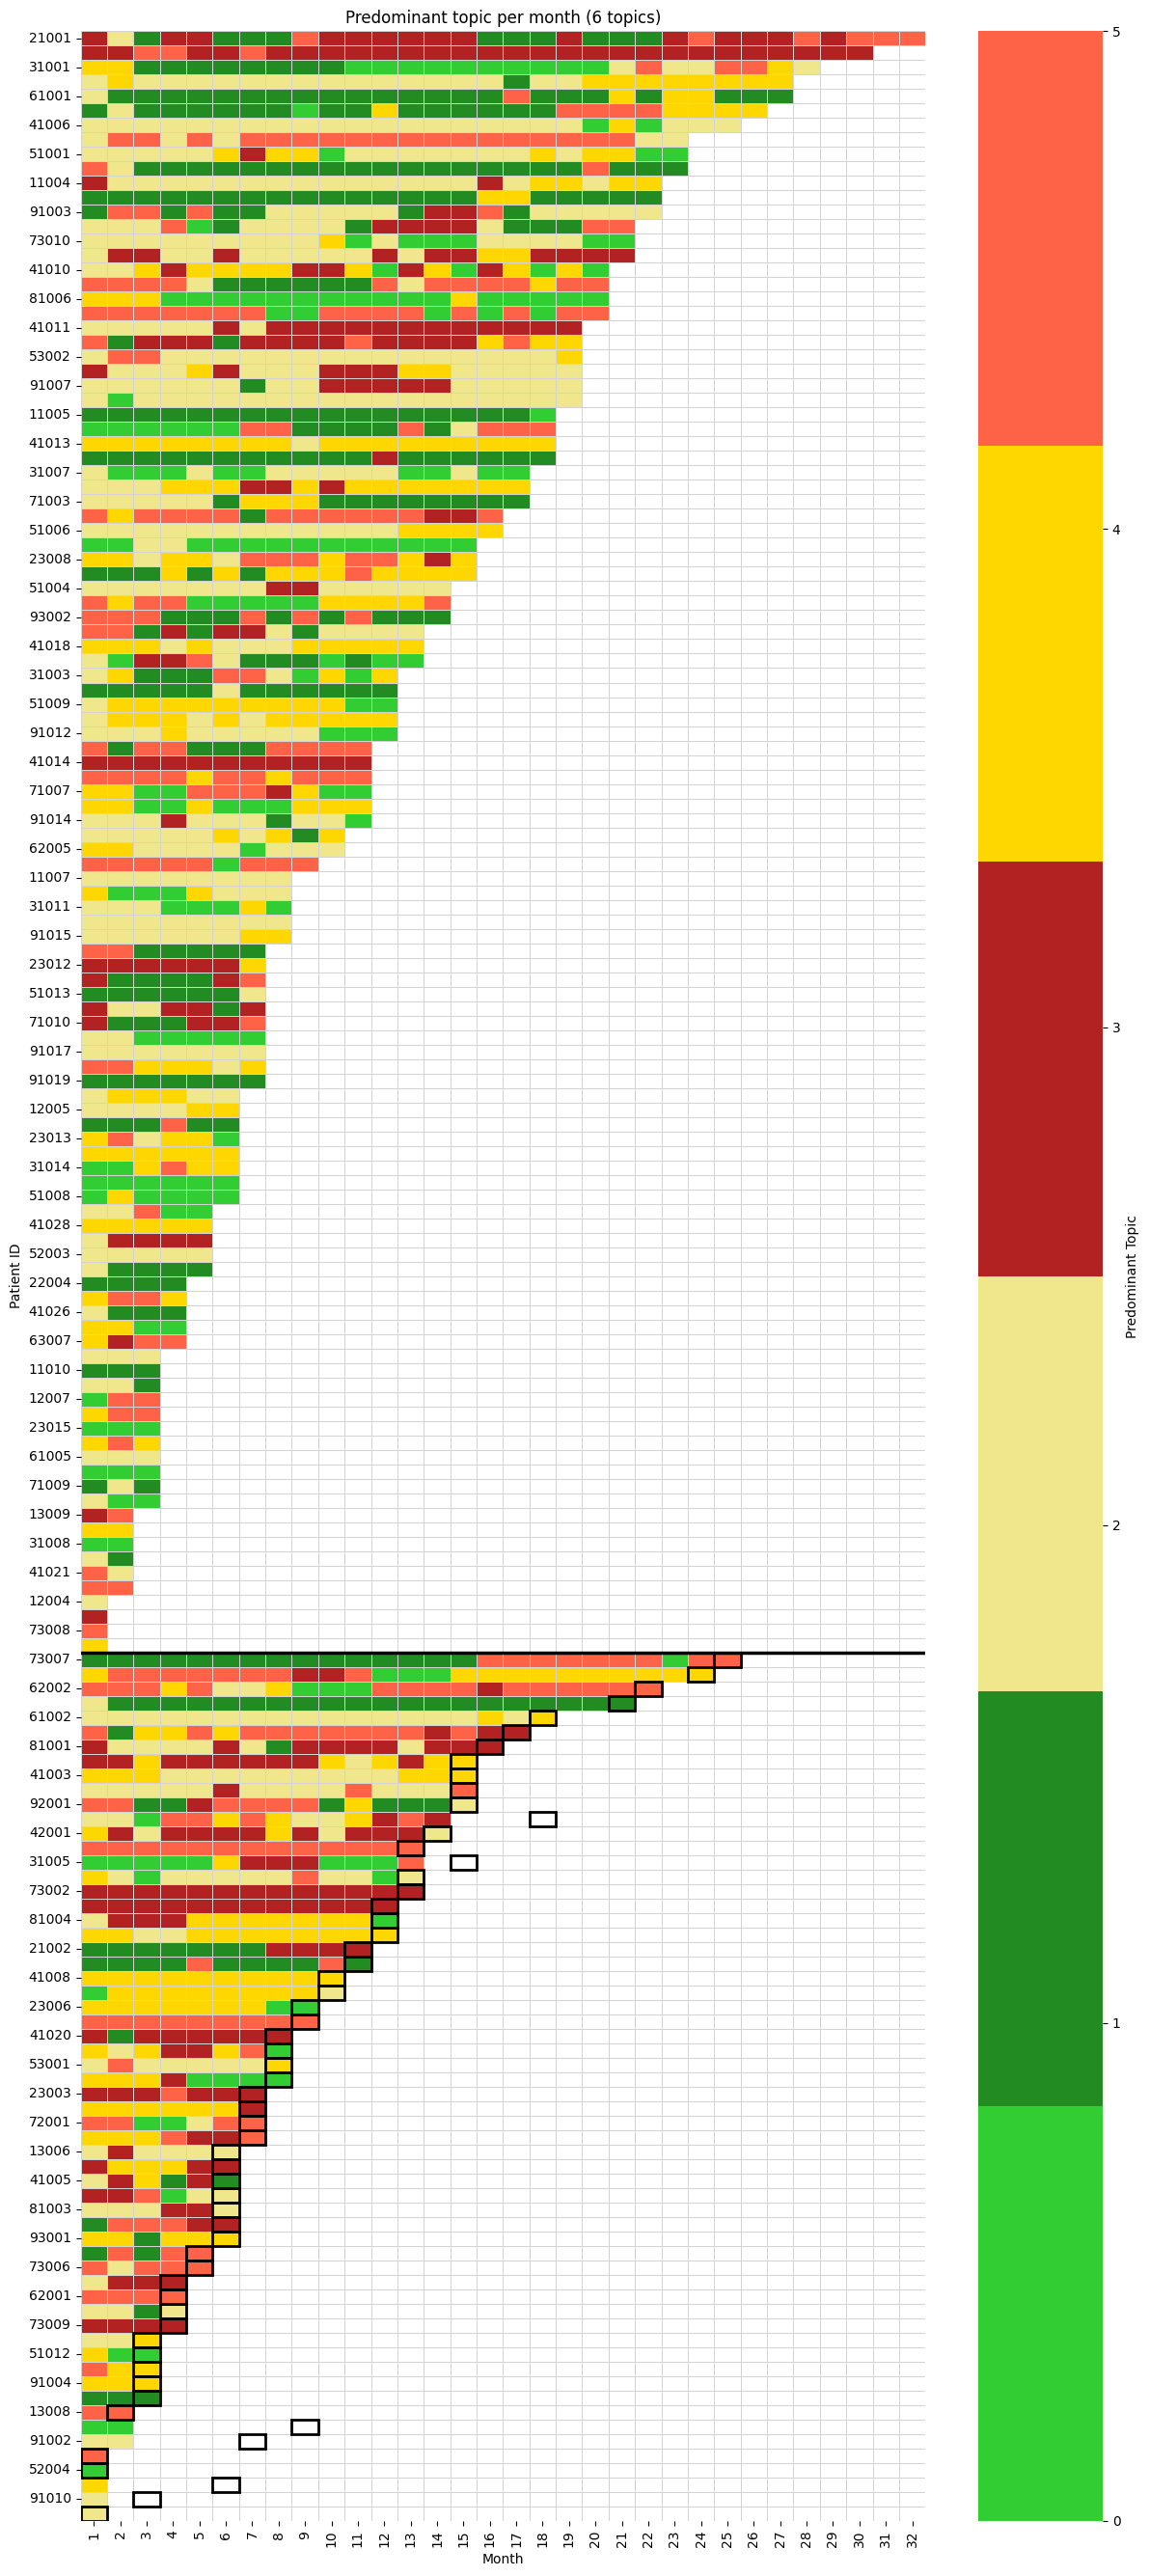

In [6]:
# Discrete colors per topic
HEATMAP_TOPIC_COLORS = {
    0: "#32cd32", 1: "#228b22", 2: "#f0e68c",
    3: "#b22222", 4: "#ffd700", 5: "#ff6347",
}

topic_cols = topic_month_columns(ordered_df)
ordered_sorted = sort_patients_for_heatmap(ordered_df, topic_cols)

plot_df = (
    ordered_sorted[["id"] + topic_cols]
    .set_index("id")
    .replace({pd.NA: np.nan})
    .apply(pd.to_numeric, errors="coerce")
)

color_list = [HEATMAP_TOPIC_COLORS[i] for i in sorted(HEATMAP_TOPIC_COLORS)]
cmap = ListedColormap(color_list)

fig, ax = plt.subplots(figsize=(12, len(plot_df) * 0.15 + 1))
sns.heatmap(
    plot_df, cmap=cmap, vmin=0, vmax=len(color_list) - 1,
    linewidths=0.5, linecolor="lightgray",
    cbar_kws={"label": "Predominant Topic"},
    mask=plot_df.isna(), ax=ax,
)

x_axis = [re.findall(r"\d+", c)[-1] for c in topic_cols]
ax.set_xticklabels(x_axis)

for i, row in ordered_sorted.iterrows():
    if row["Event"] == 1 and not pd.isna(row.get("t_evento_eb2")):
        mes_evento = int(row["t_evento_eb2"] // 30)
        if 0 <= mes_evento < len(topic_cols):
            ax.add_patch(plt.Rectangle((mes_evento, i), 1, 1, fill=False,
                                       edgecolor="black", linewidth=2))

n_no_pd = len(ordered_sorted[ordered_sorted["Event"] == 0])
ax.axhline(n_no_pd, color="black", linewidth=2.5)

ax.set_title(f"Predominant topic per month ({NUM_TOPICS} topics)")
ax.set_xlabel("Month")
ax.set_ylabel("Patient ID")
plt.tight_layout()

FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "predominant_topics_per_month.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "predominant_topics_per_month.svg", bbox_inches="tight")
print("Saved:", rel_path(FIG_DIR / "predominant_topics_per_month.svg"))
plt.show()

## 5 · Global plot 2 — Hypertopic per month (favorable vs unfavorable)

Saved: results/lda/figures/hypertopics_per_month.svg


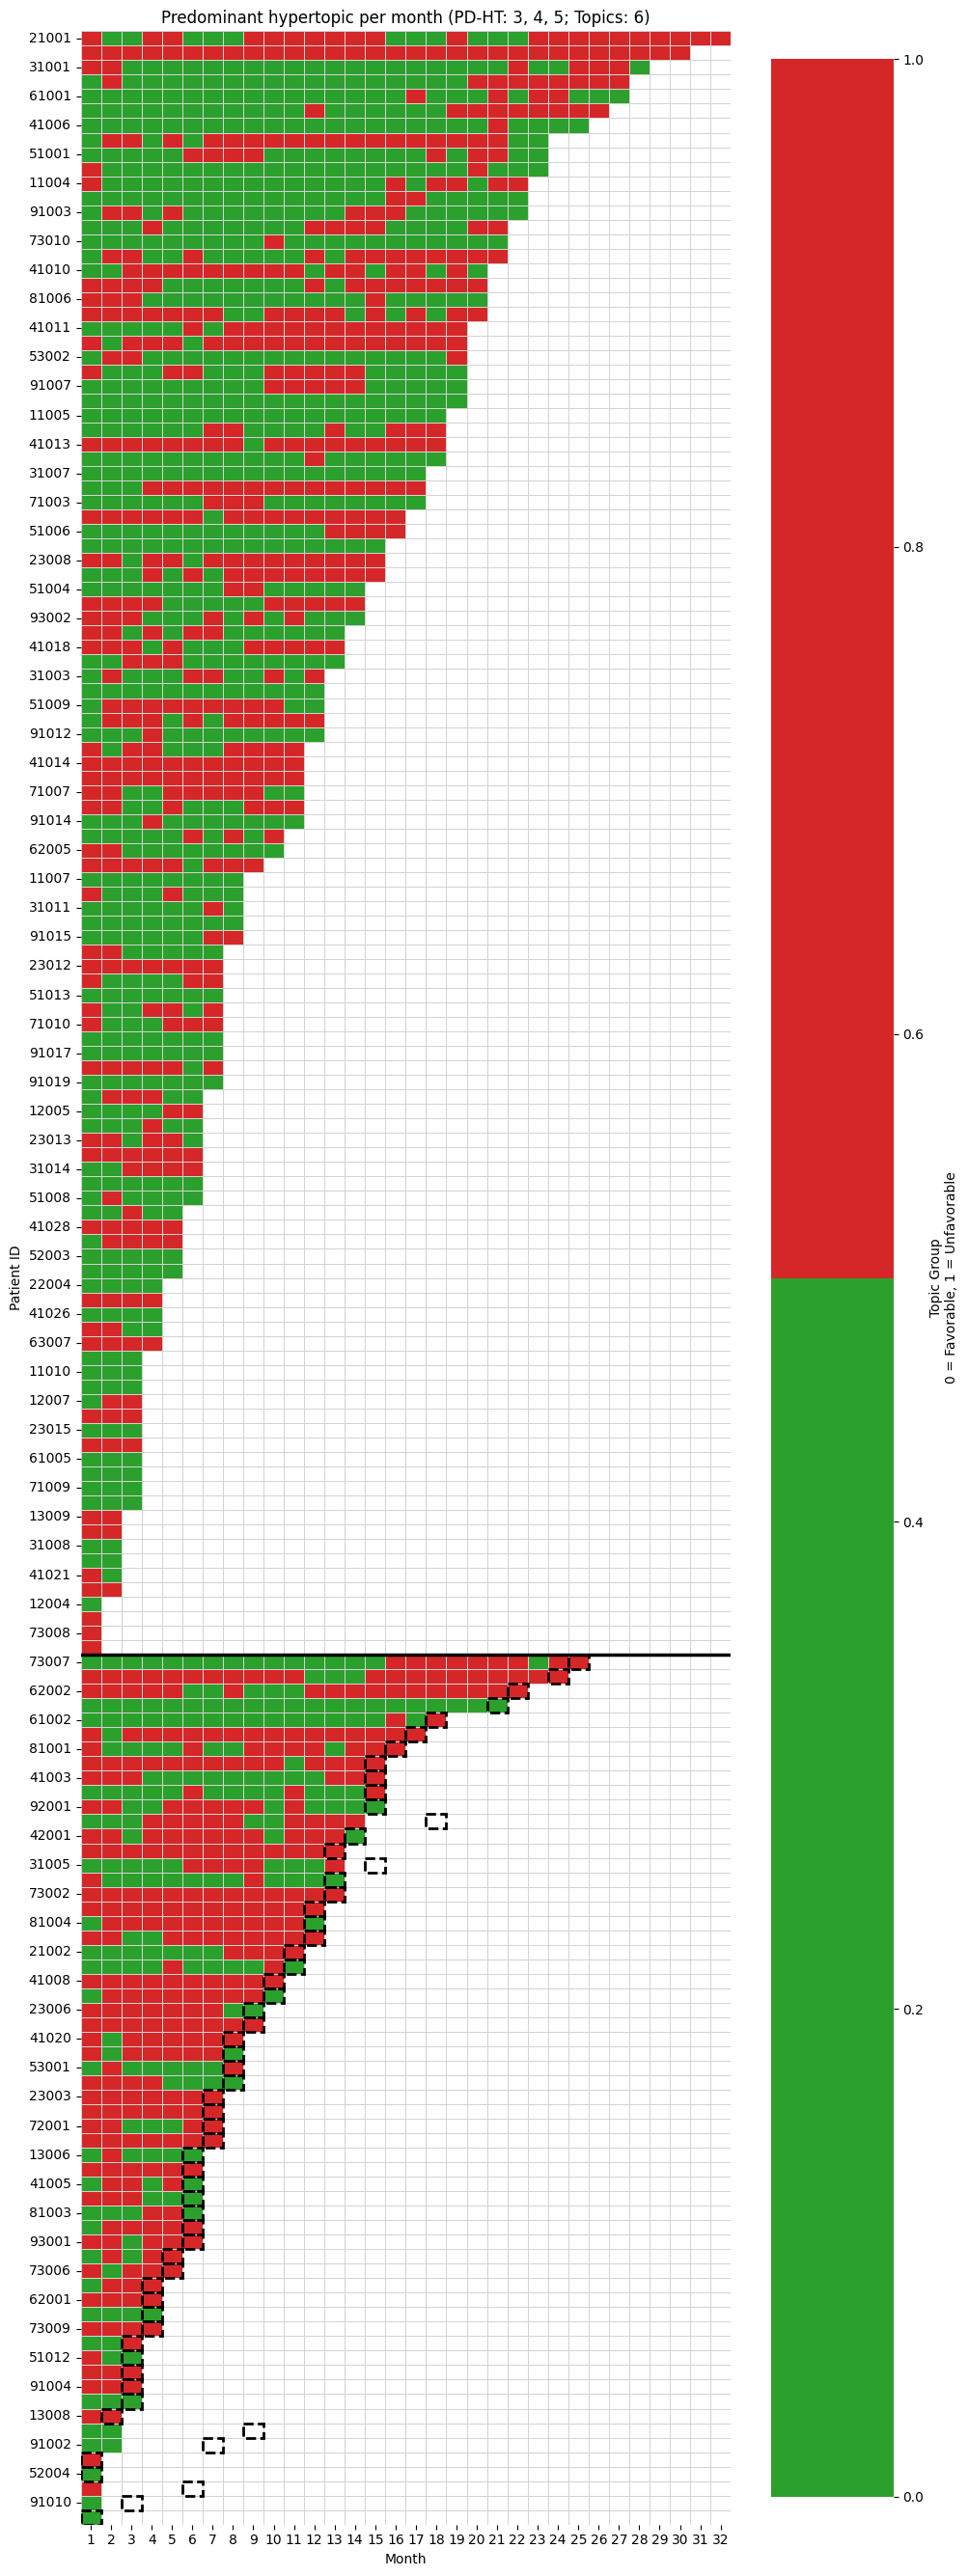

In [11]:
# Collapse the 6 topics into 2 groups (0 = favorable, 1 = unfavorable)
group_map = {0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1}
plot_df_grouped = plot_df.replace(group_map)

group_colors = ["#2ca02c", "#d62728"]
cmap_groups = ListedColormap(group_colors)

fig, ax = plt.subplots(figsize=(10, len(plot_df_grouped) * 0.15 + 1))
sns.heatmap(
    plot_df_grouped, cmap=cmap_groups, vmin=0, vmax=1,
    linewidths=0.5, linecolor="lightgray",
    mask=plot_df_grouped.isna(),
    xticklabels=x_axis,
    cbar_kws={"label": "Topic Group\n0 = Favorable, 1 = Unfavorable"},
    ax=ax,
)

for i, row in ordered_sorted.iterrows():
    if row["Event"] == 1 and not pd.isna(row.get("t_evento_eb2")):
        mes_evento = int(row["t_evento_eb2"] // 30)
        if 0 <= mes_evento < len(topic_cols):
            ax.add_patch(plt.Rectangle((mes_evento, i), 1, 1, fill=False,
                                       edgecolor="black", linewidth=2, linestyle="--"))

n_no_pd = len(ordered_sorted[ordered_sorted["Event"] == 0])
ax.axhline(n_no_pd, color="black", linewidth=2.5)

ax.set_title(f"Predominant hypertopic per month (PD-HT: 3, 4, 5; Topics: {NUM_TOPICS})")
ax.set_xlabel("Month")
ax.set_ylabel("Patient ID")
plt.tight_layout()

fig.savefig(FIG_DIR / "hypertopics_per_month.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "hypertopics_per_month.svg", bbox_inches="tight")
print("Saved:", rel_path(FIG_DIR / "hypertopics_per_month.svg"))
plt.show()

## 6 · Individual topic evolution (daily sliding windows)

LDA on a **30-day window** advancing **one day** at a time. The red dashed line marks the PD event day (clipped to the plotted range).


Saved: results/lda/figures/topic_evolution/topic_evolution_23003.png


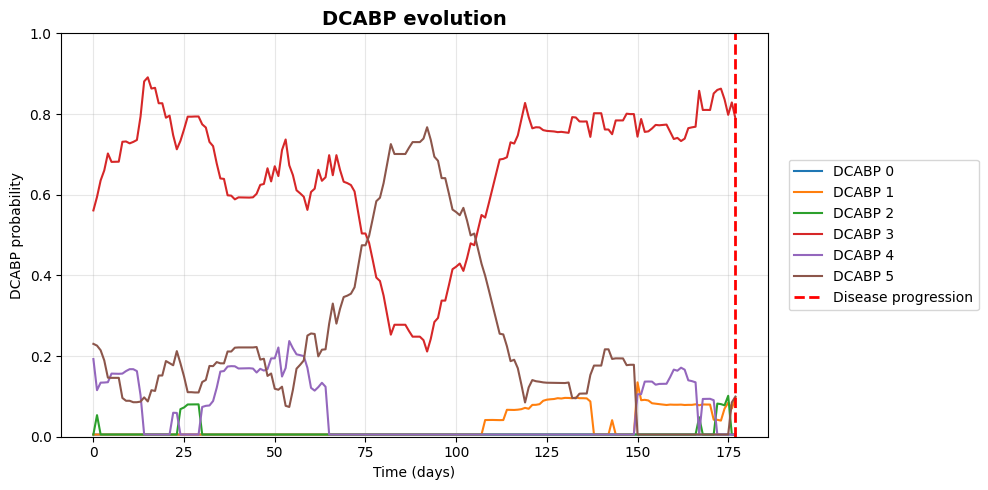

In [9]:
from monthly_topics_utils import get_topic_probabilities_daily_windows

EVOLUTION_FIG_DIR = FIG_DIR / "topic_evolution"
EVOLUTION_FIG_DIR.mkdir(parents=True, exist_ok=True)

TOPIC_LINE_COLORS = plt.cm.tab10.colors[:NUM_TOPICS]


def plot_patient_topic_evolution(
    patient_id,
    *,
    df_source=None,
    save=True,
    show=True,
):
    df_source = df_day if df_source is None else df_source
    evo = get_topic_probabilities_daily_windows(
        df_source,
        patient_id,
        lda_model,
        dictionary,
        window_size=WINDOW_SIZE,
        min_embeddings=WINDOW_SIZE,
        step=1,
    )
    if evo.empty:
        print(f"Patient {patient_id}: not enough days for a {WINDOW_SIZE}-day window.")
        return None

    fig, ax = plt.subplots(figsize=(10, 5))
    x = evo["time_window_day"]
    for t in range(NUM_TOPICS):
        ax.plot(
            x,
            evo[f"topic_{t}"],
            color=TOPIC_LINE_COLORS[t],
            label=f"DCABP {t}",
            linewidth=1.5,
        )

    meta = df_source.loc[df_source["id"] == patient_id].iloc[0]
    if float(meta.get("pd_event", 0)) == 1 and pd.notna(meta.get("pd_event_diff")):
        event_x = min(float(meta["pd_event_diff"]), float(x.max()))
        ax.axvline(event_x, color="red", linestyle="--", linewidth=2, label="Disease progression")

    ax.set_title("DCABP evolution", fontsize=14, fontweight="bold")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("DCABP probability")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    plt.tight_layout()

    out_path = EVOLUTION_FIG_DIR / f"topic_evolution_{patient_id}.png"
    if save:
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
        print("Saved:", rel_path(out_path))
    if show:
        plt.show()
    plt.close(fig)
    return None


EXAMPLE_PATIENT_ID = 23003
plot_patient_topic_evolution(EXAMPLE_PATIENT_ID)



In [ ]:
# Optional: save figures for all patients in df_day
SAVE_ALL_PATIENT_EVOLUTIONS = False

if SAVE_ALL_PATIENT_EVOLUTIONS:
    for pid in df_day["id"].dropna().unique():
        plot_patient_topic_evolution(int(pid), save=True, show=False)
    print(f"Done. Figures in {rel_path(EVOLUTION_FIG_DIR)}")

